*This notebook was created by Sergey Tomin (sergey.tomin@desy.de). Source and license info is on [GitHub](https://github.com/ocelot-collab/ocelot). June 2018.*

*This version uses the new [`Matcher`](https://www.ocelot-collab.com/docs/docu/OCELOT%20fundamentals/matcher) API. The legacy `match()` version is available [here](undulator_matching_legacy.ipynb).*

### Appendix: FODO in thin lens approximation 

*This notebook was created as an answer for a question what min/max average beta function the EuXFEL SASE1 undulator can have. The rigorous way is to ask the optics expert, but that does not give much intuition for the beam optics of this SASE line. Another problem is that FEL experts like to work with average betas. To meet all these requirements, I wrote this notebook, which also might help someone to understand how to deal with linear optics in OCELOT.*

Let's consider the FODO cell of the SASE undulator 

<img src="fodo.png" />

Introducing $d = L_{cell}/2$ as the distance between defocusing and focusing quadrupoles.

We neglect focusing effect in the vertical plane of the horizontal planar undulator.

The transfer matrix of the quadrupole in thin lens approximation:
$$
\begin{equation}
M_f = 
\begin{bmatrix}
    1 & 0 \\
    1/f & 1 
\end{bmatrix}
\end{equation}
$$
where $f = 1/kl$ is focal length, $k$ is quad strength and $l$ is the quad length. 

Drift:
$$
\begin{equation}
M_d = 
\begin{bmatrix}
    1 & d \\
    0 & 1 
\end{bmatrix}
\end{equation}
$$

In [4]:
%matplotlib inline
import sympy as sp 
sp.init_printing()

<a id='half_cell'></a>
Calculate the matrix for a half cell, starting in the middle of a defocusing quadrupole and ending in the middle of a focusing lens.

Denote $f_h = 2 f$ as the focal length of the half quadrupole.

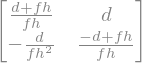

In [5]:
fh, d = sp.symbols("fh, d")

Mqf = sp.Matrix([[1, 0],[-1/fh, 1]])
Md = sp.Matrix([[1, d],[0, 1]])
Mqd = sp.Matrix([[1, 0],[1/fh, 1]])
M1 = Mqf*Md*Mqd
sp.simplify(M1)

For second half cell $f_h \to -f_h$

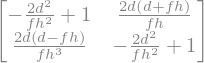

In [6]:
M2 = sp.Matrix([
[(d - fh)/-fh,           d],
[    -d/fh**2, (-d -fh)/-fh]])
M_cell = sp.simplify(M1*M2)
M_cell

#### Phase advance and stability of the FODO cell

Phase advance is related to the transfer matrix by:
$$
\cos \phi_{cell} = \frac{1}{2}Trace(M_{cell}) 
$$
Stability requires:
$$
\left|Trace(M_{cell})\right| < 2
$$

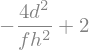

In [7]:
trace_M = sp.simplify(M_cell[0,0] + M_cell[1,1])
trace_M

#### Phase advance:
$$
\cos \phi_{cell} = \frac{1}{2}Trace(M_{cell}) = \frac{1}{2} \Big(2 - \frac{4 d^2}{f_h^2}\Big) = 1 - \frac{2 d^2}{f_h^2} = 1 - 2\frac{L_{cell}^2}{16 f^2}
$$

using trigonometric double-angle formulae:
$$
\cos 2\phi = 1-2\sin^2 \phi
$$
and finally 
$$
\boxed{\sin \phi_{cell}/2 =  \frac{L_{cell}}{4f}}
$$
#### Stability 
$$
\left| 2 - \frac{4 d^2}{f_h^2}\right| < 2
$$
rewriting 
$$
0 < \frac{4 d^2}{f_h^2} < 4 \qquad \to \qquad f_h > d
$$
Finally 
$$
\boxed{f > \frac{L_{cell}}{4}}
$$

### $\beta$ - functions

General solution of the Hill's equation $x'' + K(s)x = 0$:

\begin{equation}
\begin{cases}
x(s) = \sqrt{\varepsilon \beta(s)}\cos(\phi(s) + \phi)\\
x'(s) = -\sqrt{\frac{\varepsilon}{\beta(s)}}\Big(\alpha(s)\cos(\phi(s) + \phi) + \sin(\phi(s) + \phi)\Big)
\end{cases}
\end{equation}
$$$$
Applying initial conditions at the point $s(0) = s_0$ with $\phi(0) = 0$ and the particle coordinates $x_0, x'_0$, we will get:

\begin{equation}
\begin{cases}
\cos\phi = \frac{x_0}{\sqrt{\varepsilon \beta_0}}\\
\sin\phi = -\frac{1}{\sqrt{\varepsilon}}\Big( \frac{\alpha_0}{\sqrt{\beta_0}}x_0 + \sqrt{\beta_0}x'_0\Big)
\end{cases}
\end{equation}
inserting the result into the equation above:
\begin{equation}
\begin{bmatrix}
    x_1  \\
    x'_1 
\end{bmatrix} = 
\begin{bmatrix}
    \sqrt{\frac{\beta_1}{\beta_0}}(\cos\phi_{0\to1} + \alpha_0\sin\phi_{0\to1}) & \sqrt{\beta_1\beta_0}\sin\phi_{0\to1})\\
    \frac{(\alpha_0 - \alpha_1)\cos\phi_{0\to1} - (1 + \alpha_0\alpha_2)\sin\phi_{0\to1}}{\sqrt{\beta_1\beta_0}} & \sqrt{\frac{\beta_0}{\beta_1}}(\cos\phi_{0\to1} - \alpha_1\sin\phi_{0\to1})
\end{bmatrix}
\cdot
\begin{bmatrix}
    x_0  \\
    x'_0 
\end{bmatrix}
\end{equation}
$$$$
Now consider half of the FODO cell (see picture above) ($\phi_{0\to1} = \phi_{cell}/2$) and $\beta_0 = \beta_{min}$ and  $\beta_1 = \beta_{max}$ (we consider horizontal plane) and remembering that in the middle of the quads $\alpha = 0$. From another side, we have already calculated the transfer matrix for [a half of FODO cell](#half_cell). Collecting all together:

\begin{equation} 
\begin{bmatrix}
    \sqrt{\frac{\beta_{max}}{\beta_{min}}}\cos\frac{\phi_{cell}}{2} & \sqrt{\beta_{max}\beta_{min}}\sin\frac{\phi_{cell}}{2}\\
    -\frac{\sin\frac{\phi_{cell}}{2}}{\sqrt{\beta_{max}\beta_{min}}} & \sqrt{\frac{\beta_{min}}{\beta_{max}}}\cos\frac{\phi_{cell}}{2}
\end{bmatrix};
\qquad
\begin{bmatrix}
    1 + d/f_h &   d \\
  -d/f_h^2 & 1 - d/f_h 
\end{bmatrix}
\end{equation}

after some gymnastics with trigonometric identities (and taking into account $\sin \phi_{cell}/2 = \frac{d}{f_h}= \frac{L_{cell}}{4f}$)

$$
\beta_{max} = \frac{1 + \sin \frac{\phi_{cell}}{2}}{\sin\phi_{cell}}L_{cell}
$$

$$
\beta_{min} = \frac{1 - \sin \frac{\phi_{cell}}{2}}{\sin\phi_{cell}}L_{cell}
$$
If we neglect the fact the beta function in the drift space takes the form of a quadratic function ($\beta(s) = \beta_0 - 2\alpha_0 s + \gamma_0 s^2$) and assume instead a linear behavior, the average $\beta$-function will be
$$
\overline \beta \approx \frac{\beta_{max} + \beta_{min}}{2} = \frac{L_{cell}}{\sin\phi_{cell}}
$$

What means that minimum average beta-function will be with phase advance $\phi_{cell} = 90^0$. For SASE1 undulator $L_{cell} = 12.2$ and taking into account that our calculations were done with some level approximation:
$$
\overline \beta_{min} \approx \frac{12.2 m}{\sin 90^0} = 12.2 m
$$


### More accurate solution
Taking into account quadratic shape of the $\beta$ in the drift space and go through some simple steps, finally we will get more exact solution:
1. Twiss parameters transformation 
\begin{equation}
\begin{bmatrix}
    \beta  \\
    \alpha \\
    \gamma
\end{bmatrix}_1 = 
\begin{bmatrix}
    C^2 & -2SC & S^2\\
    -C C' & SC' + S'C & -SS'\\
    C'^2 & -2 S'C' & S'^2
\end{bmatrix}
\cdot
\begin{bmatrix}
    \beta  \\
    \alpha \\
    \gamma
\end{bmatrix}_0
\end{equation}
Where $C,S, C', S'$ are elements of the transfer matrix
\begin{equation}
M = 
\begin{bmatrix}
    C & S \\
    C' & S' 
\end{bmatrix}
\end{equation}

2. twiss parameters after the thin quadrupole:
$$
\beta_1 = \beta_0 \\
\alpha_1 = -\frac{\beta_0}{f} + \alpha_0 \\
\gamma_1 = \frac{1}{f^2} - 2 \frac{\alpha_0}{f} + \gamma_0
$$
In the middle of the quadrupole $\alpha_0 = 0$ then
$$
\alpha_1 = -\frac{\beta_0}{f_h}
$$
3. In the drift space $\beta$ behave:
$$
\beta(s) = \beta_0 - 2\alpha_0 s + \gamma_0 s^2
$$
4. Because FODO cell is symetric and we are considering the thin lens approximation the average $\overline \beta$ is:
$$
\overline \beta = \frac{2}{L}\int_0^{L/2}\left(\beta_0 - 2\alpha_0 s + \gamma_0s^2 \right)ds = \beta_0 - \frac{\alpha_0 L}{2} + \gamma_0\frac{L^2}{12}
$$
5. Inserting expression for $\beta_{min}$ and express focal length against the phase advance we will get:
$$
\boxed{\overline \beta = \frac{L}{6 \sin\phi_{cell}}\big(5 + \cos\phi_{cell} \big)}
$$

<div class="alert alert-block alert-info">
<b>Note:</b> The result looks simple, probably this expression can be found in some handbooks which I am not aware of. 
</div>


$$$$
The minimum possible average $\overline\beta_{min}$ will be with $\frac{d \overline \beta}{d\phi_{cell}} = 0$ what gives us $\phi_{cell} = \pi - \arctan 2\sqrt 6 \approx 101^0$. 

And for our case $L_{cell} = 12.2 m$ it will be 
$$
\overline \beta_{min}  \approx 9.96
$$

Might be useful to find condition for minimum possible $\beta_{max}$ 
$$
\frac{d}{d\phi}\beta_{max} = 0
$$

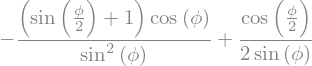

In [8]:
phi = sp.Symbol("phi")
sp.diff((1 + sp.sin(phi/2))/sp.sin(phi), phi)

In [9]:
import numpy as np
from scipy.optimize import root
from matplotlib import pyplot as plt
fun = lambda phi: -(np.sin(phi/2) + 1)*np.cos(phi)/np.sin(phi)**2 + np.cos(phi/2)/(2*np.sin(phi))
res = root(fun, 0.1)
print("Cell phase advance for minimum possible bmax: phi = ", res.x*180/np.pi)

Cell phase advance for minimum possible bmax: phi =  [76.34541525]


### SASE1 undulator. Numerical simulation

The matching examples below use `MatchProblem` from the new Matcher module.

initializing ocelot...


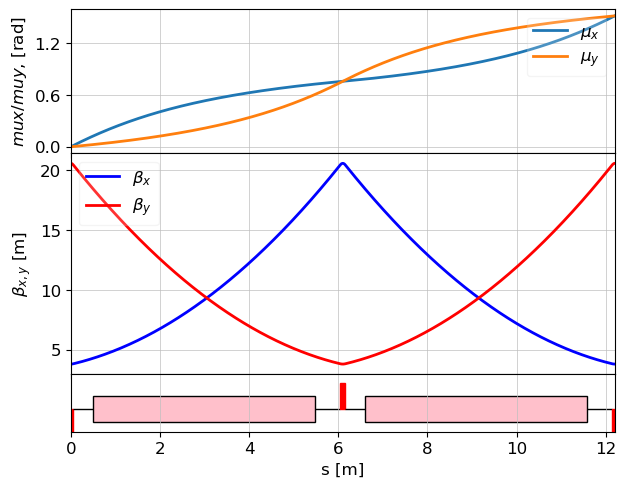

In [10]:
%matplotlib inline
from ocelot import *
from ocelot.gui.accelerator import *
try:
    from scipy.integrate import simpson
except ImportError:
    from scipy.integrate import simps as simpson
from ocelot.cpbd import optics
from ocelot.cpbd.matcher import MatchProblem

d1 = Drift(l=0.43065, eid='d1')
d2 = Drift(l=0.55565, eid='d2')
l = 0.1137
k = 2*0.1137/l

qd = Quadrupole(l=l/2, k1=-k, tilt=0.0)
qf = Quadrupole(l=l, k1=k, tilt=0.0)
K = 3
u40 = Undulator(lperiod=0.04, nperiods=125, Kx=K, Ky=0.0)
m1 = Marker()
m2 = Marker()
fodo_cell = [m1, qd, d1, u40, d2, qf, d1, u40, d2, qd, m2]
fodo_lat = MagneticLattice(fodo_cell)

tws = twiss(fodo_lat, nPoints=1000)

plot_opt_func(fodo_lat, tws, top_plot=["mux", "muy"], legend=False)
plt.show()

min(beta_av) =  9.991835898036324 m


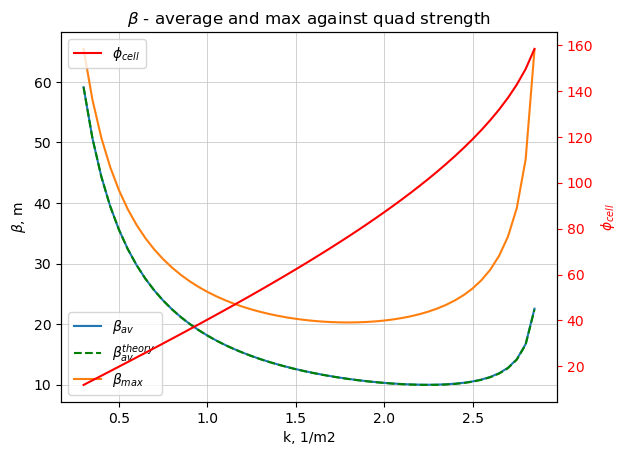

In [11]:
def beta(k):
    qd.k1 = -k
    qf.k1 = k
    fodo_lat.update_transfer_maps()
    tws = twiss(fodo_lat, nPoints=1000)
    bx = np.array([tw.beta_x for tw in tws])
    s = np.array([tw.s for tw in tws])
    bx_av = simpson(bx, x=s)/fodo_lat.totalLen
    phi = tws[-1].mux
    L = fodo_lat.totalLen
    bx_av_th = L/6 * (5 + np.cos(phi))/np.sin(phi)
    return bx_av, bx.max(), bx.min(), tws[-1].mux*180/np.pi, bx_av_th

k = np.arange(0.3, 2.9, 0.05)
Bx_min = []
Bx_max = []
Bx_av = []
Bx_av_theory = []
Phi = []
for k1 in k:
    bx_av, bx_max, bx_min, phi, bx_av_th = beta(k1)
    Bx_min.append(bx_min)
    Bx_max.append(bx_max)
    Bx_av.append(bx_av)
    Phi.append(phi)
    Bx_av_theory.append(bx_av_th)
    
fig, ax1 = plt.subplots()
plt.title(r"$\beta$ - average and max against quad strength")
ax1.plot(k, Bx_av, label=r"$\beta_{av}$")
ax1.plot(k, Bx_av_theory,"g--", label=r"$\beta_{av}^{theory}$")
ax1.plot(k, Bx_max, label=r"$\beta_{max}$")
ax1.set_ylabel(r"$\beta$, m")
ax1.set_xlabel("k, 1/m2")
plt.legend()
print("min(beta_av) = ", np.min(Bx_av), "m" )
ax2 = ax1.twinx()
ax2.plot(k, Phi, "r", label=r"$\phi_{cell}$")
ax2.set_ylabel(r"$\phi_{cell}$", color='r')
ax2.tick_params('y', colors='r')
plt.legend()
plt.grid(False)
plt.show()

### Limitations

The maximum possible strength of the undulator quadrupoles is  $k_{max} = 1.94729$ which means that the minimum average beta-function is close to 10 m (see the Figure above). 

Now we need to consider the limitations of the matching sections.

## Inverse the task

Find the quad strength and FODO cell params if beta average is defined

### FODO estimator

In [12]:
from scipy.optimize import root

def fodo_estimator(beta_av, Lcell, lq=0.1137):
    fun = lambda phi: Lcell/6 * (5 + np.cos(phi))/np.sin(phi) - beta_av
    res = root(fun, 0.1)
    phi = res.x[0]
    b_av = Lcell/6 * (5 + np.cos(phi))/np.sin(phi)
    f = Lcell/(4*np.sin(phi/2))
    kq = 1/f/lq
    bmax = (1 + np.sin(phi/2))/np.sin(phi)*Lcell
    bmin = (1 - np.sin(phi/2))/np.sin(phi)*Lcell
    return kq, phi, bmin, bmax, b_av
    
kq, phi, bmin, bmax, b_av = fodo_estimator(beta_av=11, Lcell=12.2)
print("k1 = ", kq, "1/m^2")
print("bmin / bmax = ", bmin, "/", bmax, "m")
print("calculated beta_av = ", b_av, "m")
print("phi = ", phi*180/np.pi, "deg")

k1 =  1.771751963648942 1/m^2
bmin / bmax =  4.851965262428619 / 20.314939511625177 m
calculated beta_av =  11.000000000000059 m
phi =  75.8191420392388 deg


### FODO correction due to undulator focusing 

In [13]:
def fodo_correction_SASE1(beta_av=60, K=3):
    kq, phi, bmin, bmax, b_av = fodo_estimator(beta_av=beta_av, Lcell=12.2)
    
    print("Estimation: beta_x = ", np.round(bmin,3), "; beta_y = ", np.round(bmax, 3),
          "; phi = ", np.round(phi*180/np.pi), "deg"
          "; kf/kd = ", np.round(kq, 4),"/", np.round(-kq, 4))
    
    # SASE1 FODO cell
    d1 = Drift(l=0.43065, eid='d1')
    d2 = Drift(l=0.55565, eid='d2')
    qd = Quadrupole(l=0.1137/2, k1=-kq, tilt=0.0)
    qf = Quadrupole(l=0.1137, k1=kq, tilt=0.0)
    u40 = Undulator(lperiod=0.04, nperiods=125, Kx=K, Ky=0.0)
    m1 = Marker()
    m2 = Marker()
    fodo_cell = [m1, qd, d1, u40, d2, qf, d1, u40, d2, qd, m2]
    fodo_lat = MagneticLattice(fodo_cell)
    
    tws = Twiss()
    tws.beta_x = bmin
    tws.beta_y = bmax
    tws.E = 14
    
    problem = MatchProblem(fodo_lat, tws, periodic=True)
    problem.vary_element(qf, quantity="k1", limits=(-3, 3), name="qf.k1")
    problem.vary_element(qd, quantity="k1", limits=(-3, 3), name="qd.k1")
    problem.target_twiss(m2, "mux", phi, weight=1e6, tol=1e-8)
    problem.target_twiss(m2, "muy", phi, weight=1e6, tol=1e-8)
    result = problem.solve(solver="ls_trf", max_iter=2000, tol=1e-10)
    
    kf = qf.k1
    kd = qd.k1
    
    tws = twiss(fodo_lat, tws0=tws, nPoints=1000)
    print("Correction: beta_x = ", np.round(tws[0].beta_x, 3), 
          "beta_y = ", np.round(tws[0].beta_y, 3), 
          " kf/kd = ", np.round(kf,4), "/", np.round(kd,4),
          "; success = ", result.success)
    #plot_opt_func(fodo_lat, tws, top_plot=["mux", "muy"], legend=False)
    #plt.show()
    return kf, kd, bmin, bmax


### Current lattice $\overline\beta \approx 32$ m

In [14]:
import sase1_lattice as sase1

emit_x  = 0.0
emit_y  = 0.0
emit_xn  = 0.0
emit_yn  = 0.0
beta_x  = 10.506745988156398
beta_y  = 42.02704133328497
alpha_x = 0.676085898798978
alpha_y = -2.1449229692237783
Dx      = 0.0
Dy      = 0.0
Dxp     = 0.0
Dyp     = 0.0
mux     = 0.0
muy     = 0.0
nu_x    = 0.0
nu_y    = 0.0
E       = 14
s        = 0.0



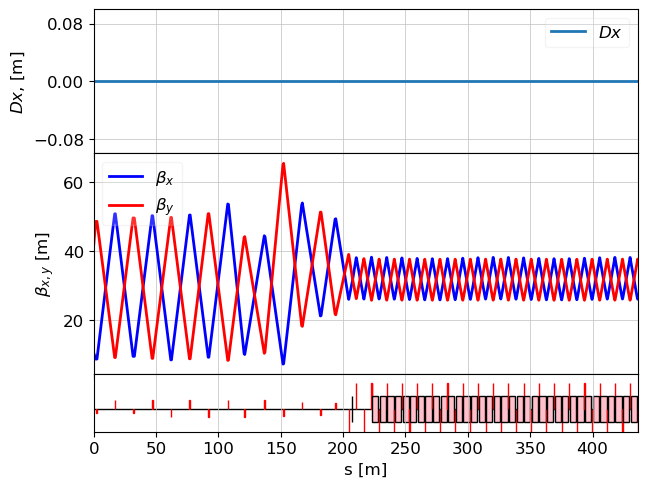

In [15]:
lat = MagneticLattice(sase1.cell)#, stop=sase1.fodo_match)
print(sase1.tws)
#sase1.tws.beta_x = 15
#sase1.tws.beta_y = 50
tws = twiss(lat, tws0=sase1.tws)
plot_opt_func(lat, tws, legend=False)
plt.show()

### $\overline \beta = 60$ m

The matching problem uses explicit quadrupole bounds.

Estimation: beta_x =  54.076 ; beta_y =  66.34 ; phi =  12.0 deg; kf/kd =  0.2937 / -0.2937
Correction: beta_x =  54.076 beta_y =  66.34  kf/kd =  0.2648 / -0.2583 ; success =  True
Matching success = True ; merit = 0.0


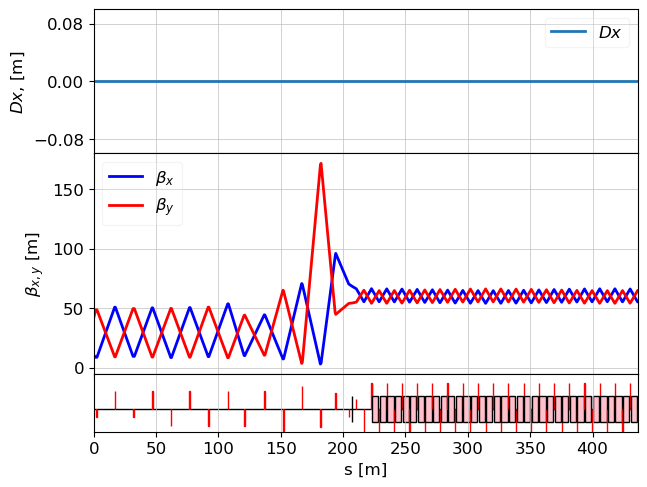

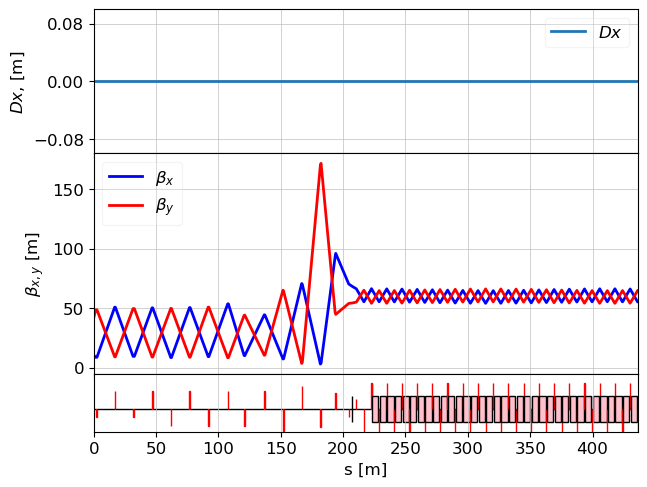

In [16]:
kf, kd, bmin, bmax = fodo_correction_SASE1(beta_av=60, K=3)


# Because of variable redundancy, we can help the optimizer find a more elegant solution.
# Comment these lines or change initial conditions if you want to play with matching.
sase1.qf_2177_t2.k1 = -0.2244
sase1.qf_2192_t2.k1 = 0.2309
sase1.qf_2207_t2.k1 = -0.1911
sase1.qf_2218_t2.k1 = 0.1653
sase1.qa_2229_t2.k1 = -0.0881
sase1.qa_2235_t2.k1 = 0.0953
# These quadrupoles are shared with the lattice part before fodo_match,
# so they must be set before solving the upstream matching section.
sase1.qa_2241_sa1.k1 = kd
sase1.qa_2247_sa1.k1 = kf
sase1.qa_2247_sa1_h.k1 = kf


problem = MatchProblem(lat, sase1.tws, periodic=False)
problem.vary_element(sase1.qf_2177_t2, quantity="k1", limits=[-0.654, 0], name=sase1.qf_2177_t2.id + ".k1")
problem.vary_element(sase1.qf_2192_t2, quantity="k1", limits=[0 ,0.654], name=sase1.qf_2192_t2.id + ".k1")
problem.vary_element(sase1.qf_2207_t2, quantity="k1", limits=[-0.654, 0], name=sase1.qf_2207_t2.id + ".k1")
problem.vary_element(sase1.qf_2218_t2, quantity="k1", limits=[0 ,0.654], name=sase1.qf_2218_t2.id + ".k1")
problem.vary_element(sase1.qa_2229_t2, quantity="k1", limits=[-1.94, 0], name=sase1.qa_2229_t2.id + ".k1")
problem.vary_element(sase1.qa_2235_t2, quantity="k1", limits=[0, 1.94], name=sase1.qa_2235_t2.id + ".k1")


problem.target_twiss(sase1.fodo_match, "beta_x", bmax, weight=1e6, tol=1e-5)
problem.target_twiss(sase1.fodo_match, "beta_y", bmin, weight=1e6, tol=1e-5)
problem.target_twiss(sase1.fodo_match, "alpha_x", 0.0, weight=1e6, tol=1e-5)
problem.target_twiss(sase1.fodo_match, "alpha_y", 0.0, weight=1e6, tol=1e-5)
result = problem.solve(solver="ls_trf", max_iter=2000, tol=1e-10)
print("Matching success =", result.success, "; merit =", result.merit)

tws = twiss(lat, tws0=sase1.tws)
plot_opt_func(lat, tws, legend=False)
plt.show()


### $\overline \beta = 11$ m

The same Matcher setup is used for a stronger focusing solution.

Estimation: beta_x =  4.852 ; beta_y =  20.315 ; phi =  76.0 deg; kf/kd =  1.7718 / -1.7718
Correction: beta_x =  4.852 beta_y =  20.315  kf/kd =  1.7811 / -1.7755 ; success =  True
Matching success = True ; merit = 1.1194006433165288e-07


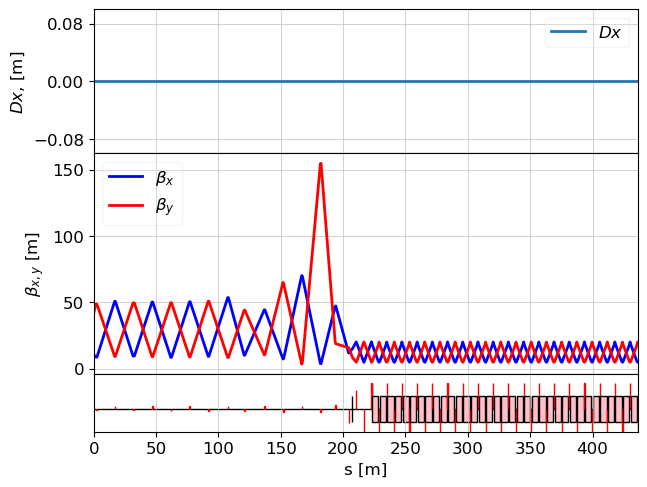

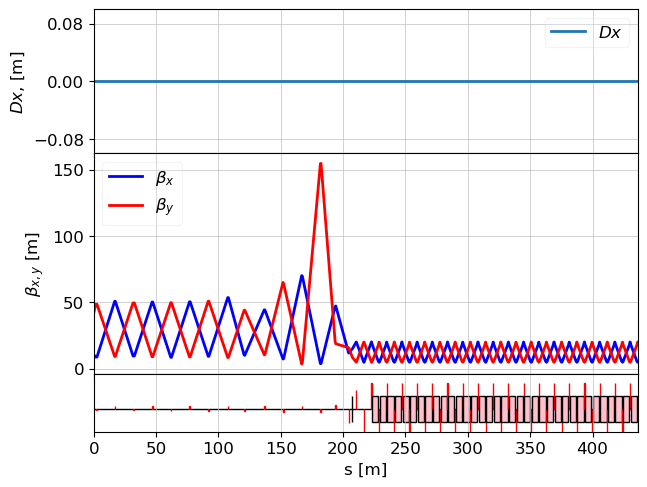

In [17]:
kf, kd, bmin, bmax = fodo_correction_SASE1(beta_av=11, K=3)

# Because of variable redundancy, we can help the optimizer find a more elegant solution.
# Comment these lines or change initial conditions if you want to play with matching.
sase1.qf_2177_t2.k1 = -0.2227
sase1.qf_2192_t2.k1 = 0.211
sase1.qf_2207_t2.k1 = -0.2176
sase1.qf_2218_t2.k1 = 0.2392
sase1.qa_2229_t2.k1 = -0.9728
sase1.qa_2235_t2.k1 = 1.3215

# These quadrupoles are shared with the lattice part before fodo_match,
# so they must be set before solving the upstream matching section.
sase1.qa_2241_sa1.k1 = kd
sase1.qa_2247_sa1.k1 = kf
sase1.qa_2247_sa1_h.k1 = kf


problem = MatchProblem(lat, sase1.tws, periodic=False)
problem.vary_element(sase1.qf_2177_t2, quantity="k1", limits=[-0.654, 0], name=sase1.qf_2177_t2.id + ".k1")
problem.vary_element(sase1.qf_2192_t2, quantity="k1", limits=[0 ,0.654], name=sase1.qf_2192_t2.id + ".k1")
problem.vary_element(sase1.qf_2207_t2, quantity="k1", limits=[-0.654, 0], name=sase1.qf_2207_t2.id + ".k1")
problem.vary_element(sase1.qf_2218_t2, quantity="k1", limits=[0 ,0.654], name=sase1.qf_2218_t2.id + ".k1")
problem.vary_element(sase1.qa_2229_t2, quantity="k1", limits=[-1.94, 0], name=sase1.qa_2229_t2.id + ".k1")
problem.vary_element(sase1.qa_2235_t2, quantity="k1", limits=[0, 1.94], name=sase1.qa_2235_t2.id + ".k1")

problem.target_twiss(sase1.fodo_match, "beta_x", bmax, weight=1e6, tol=1e-5)
problem.target_twiss(sase1.fodo_match, "beta_y", bmin, weight=1e6, tol=1e-5)
problem.target_twiss(sase1.fodo_match, "alpha_x", 0.0, weight=1e6, tol=1e-5)
problem.target_twiss(sase1.fodo_match, "alpha_y", 0.0, weight=1e6, tol=1e-5)
result = problem.solve(solver="ls_trf", max_iter=2000, tol=1e-10)

print("Matching success =", result.success, "; merit =", result.merit)

tws = twiss(lat, tws0=sase1.tws)
plot_opt_func(lat, tws, legend=False)
plt.show()
